In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

import muutils.dbg
from muutils.dbg import dbg, dbg_tensor

from attention_motifs.util import plot_figs, load_activations
from attention_motifs.bins import Bins
from attention_motifs.math.cos_sim import cosine_similarity_matrix
from attention_motifs.math.math import scaled_beta

muutils.dbg.DBG_TENSOR_ARRAY_SUMMARY_DEFAULTS["sparkline_logy"] = True

In [2]:
MODEL_NAME: str = "pythia-14m"
MODEL_CFG: dict
PROMPTS: list[dict]
ACTIVATIONS: list[np.lib.npyio.NpzFile]
MODEL_CFG, PROMPTS, ACTIVATIONS = load_activations(MODEL_NAME)

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 0, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.03 σ=0.06 x̃=0.01 R=[0.00,1.00] ℙ=|█▄▃▂▂▁▁| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.72 x̃=0.42 R=[0.07,9.07] ℙ=|█▂▁▁  ▁| shape=32 dtype=float64
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.5028665755143116, 3.3591068947681113, 5.945549359595631e-05, 1.4501015723967745)


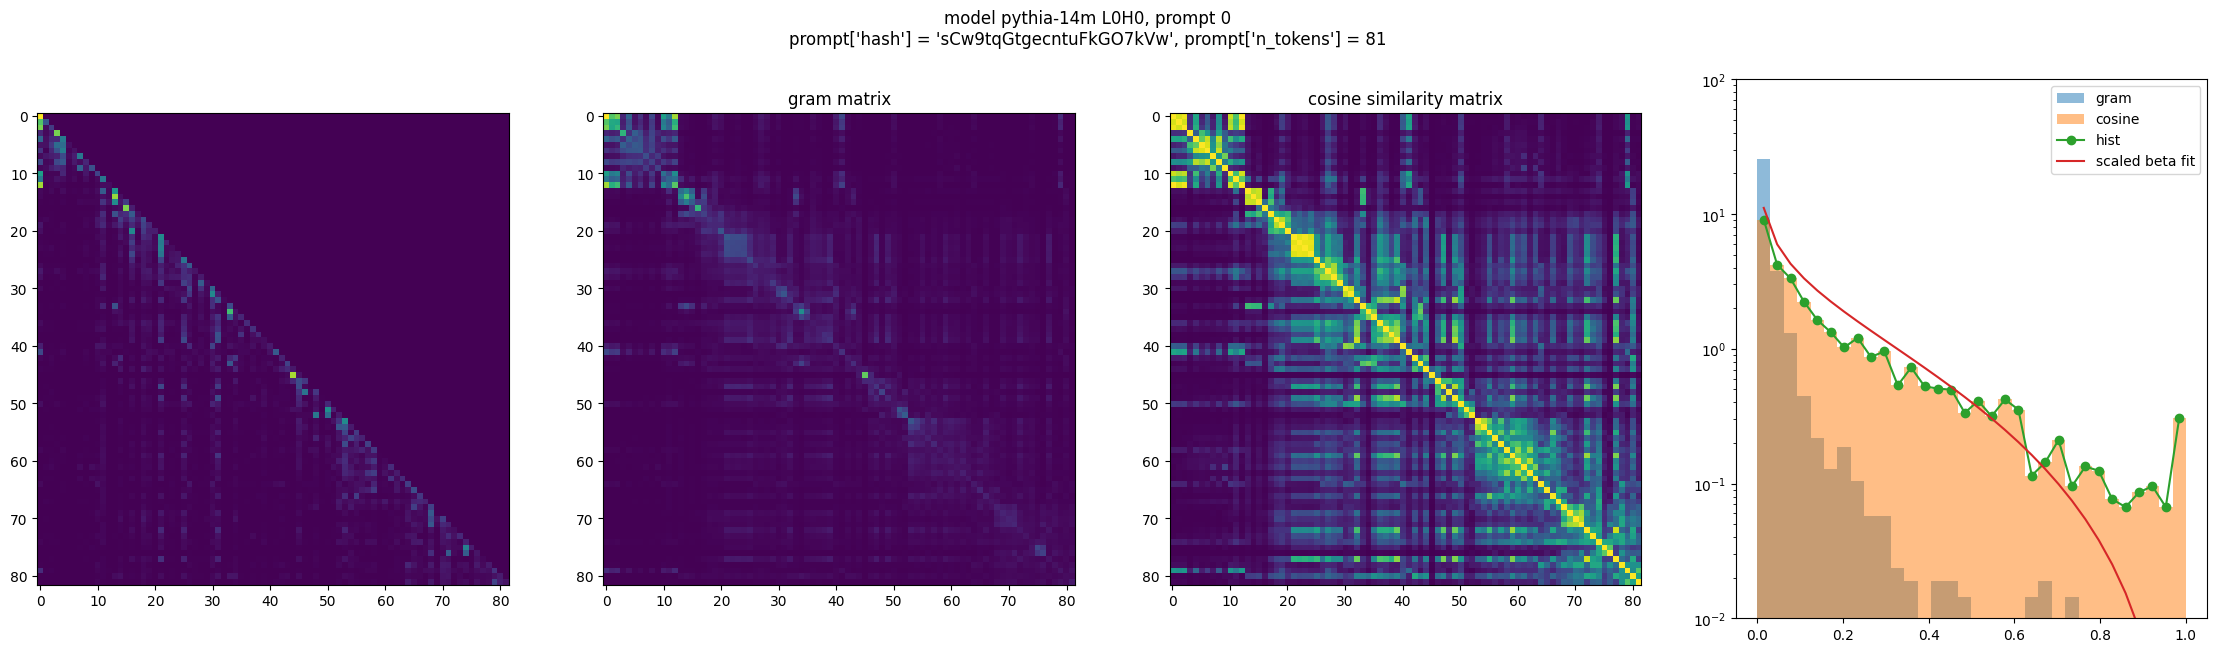

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 1, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.01 σ=0.08 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▃▃▂▂▂| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=5.24 x̃=0.04 R=[0.00,30.19] ℙ=|█     ▁| shape=32 dtype=float64
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.2053555422608469, 675.8444246748181, 6.399619804517987e-27, 13.815184282908314)


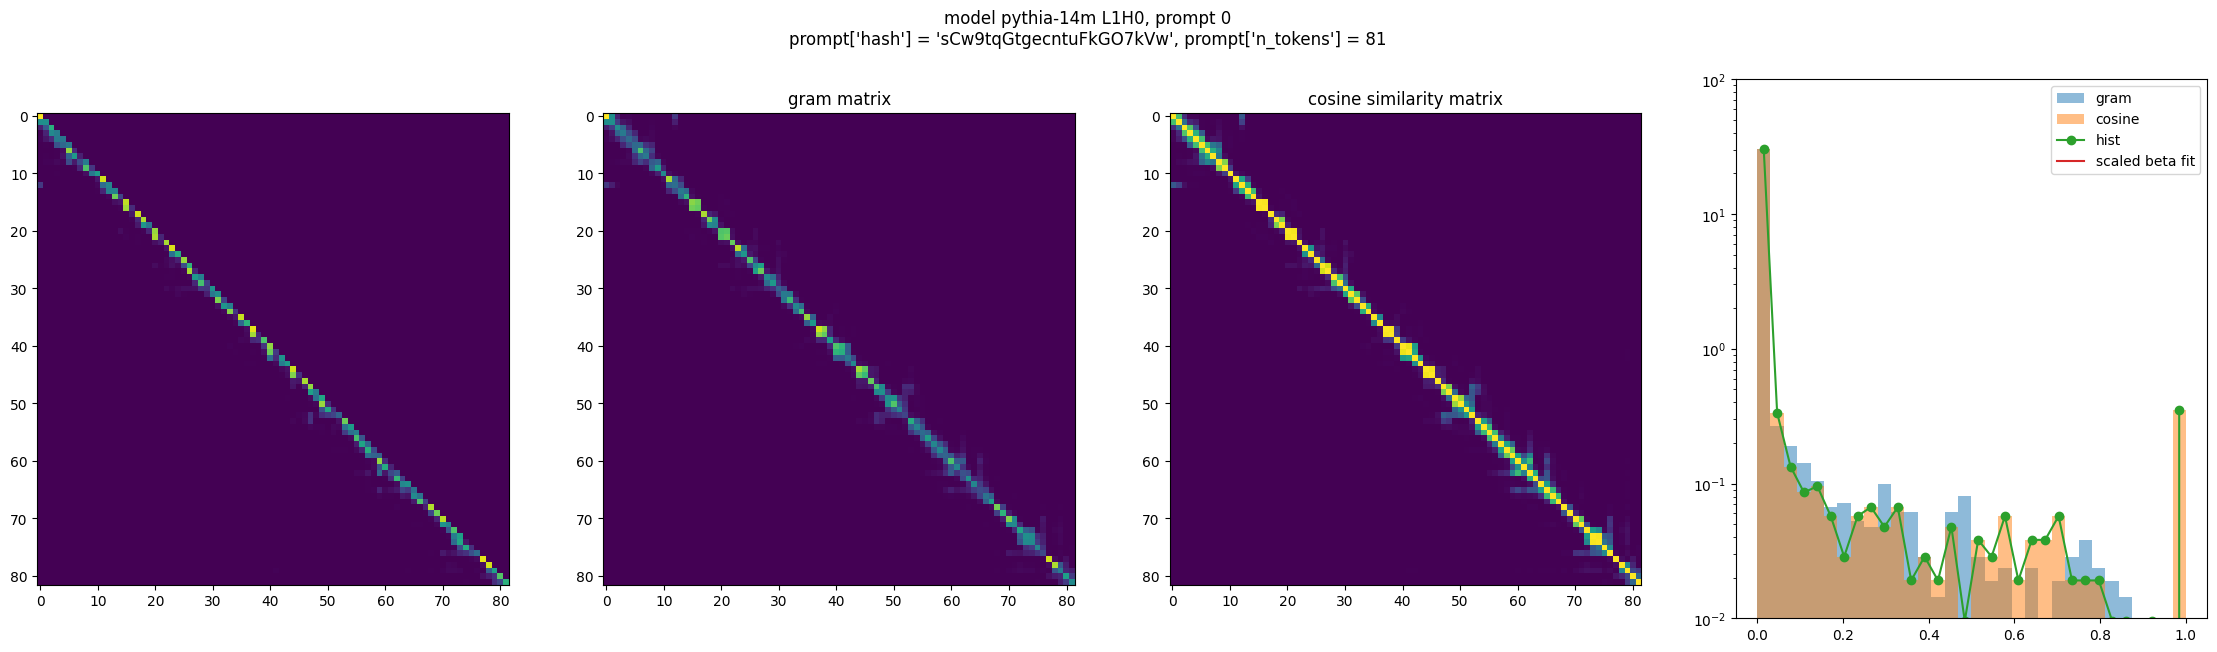

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 2, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.05 σ=0.06 x̃=0.03 R=[0.00,1.00] ℙ=|█▅▃▁▁  | shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.71 x̃=0.66 R=[0.22,2.25] ℙ=|█▅ ▄▂▄▅| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (1.558097266676236, 9.25256269965776, 0.005793190151993034, 2.264399464632876)


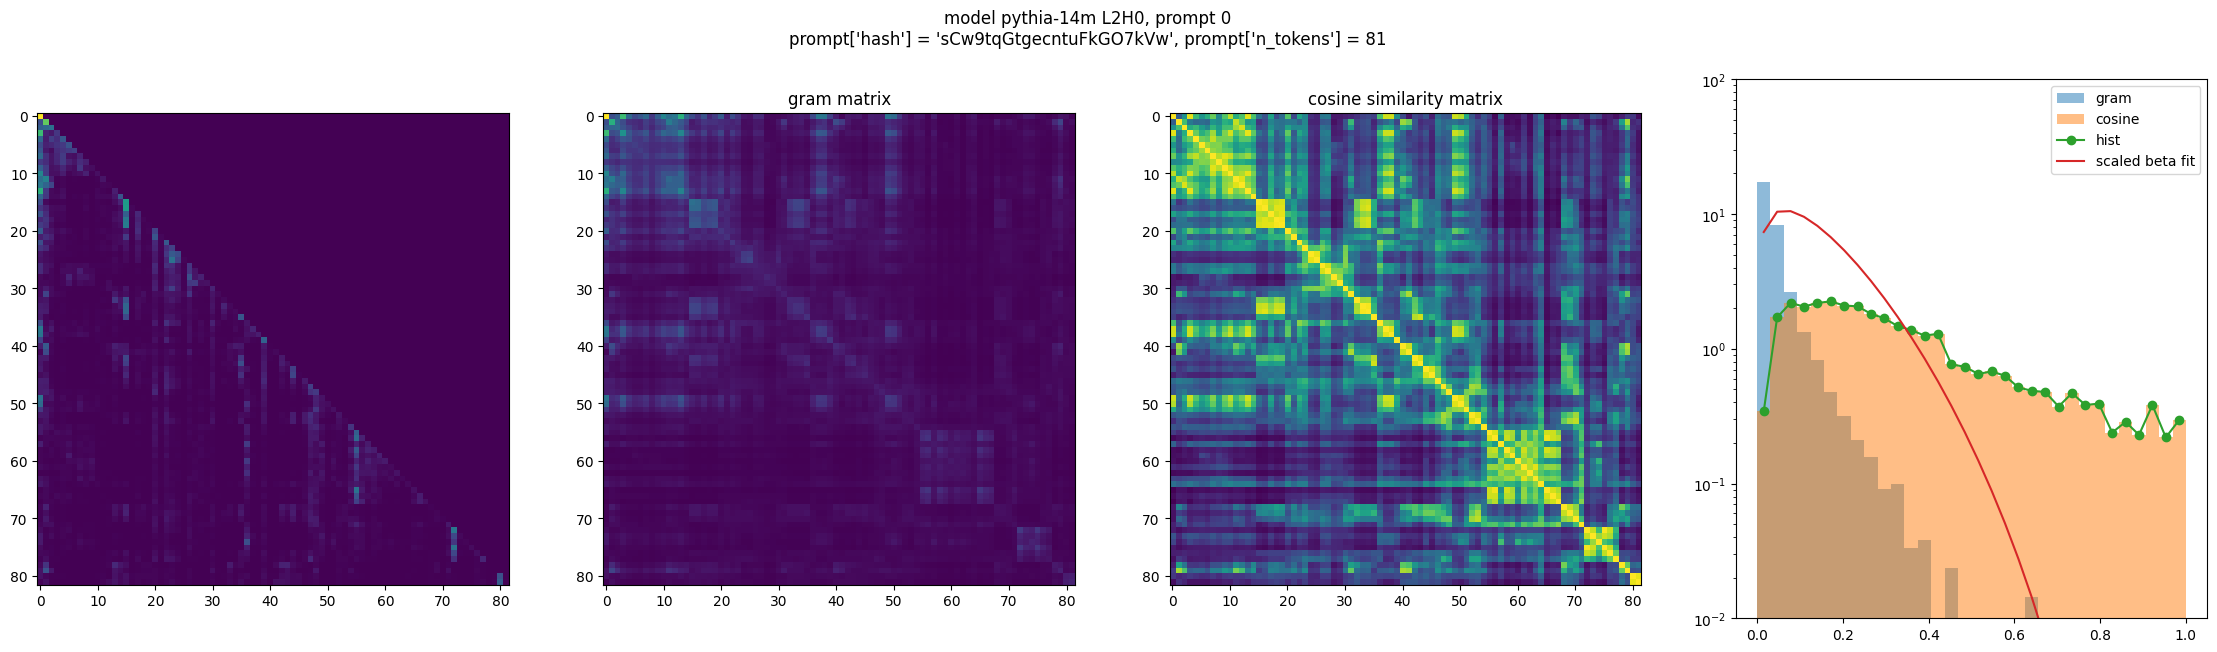

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 3, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.24 σ=0.21 x̃=0.18 R=[0.00,1.00] ℙ=|█▇▆▆▅▅▄| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.52 x̃=0.77 R=[0.37,2.70] ℙ=|█▆▅▅▄ ▂| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.8016997054032218, 0.5336249039329701, -0.060874522119032576, 1.060874815969878)


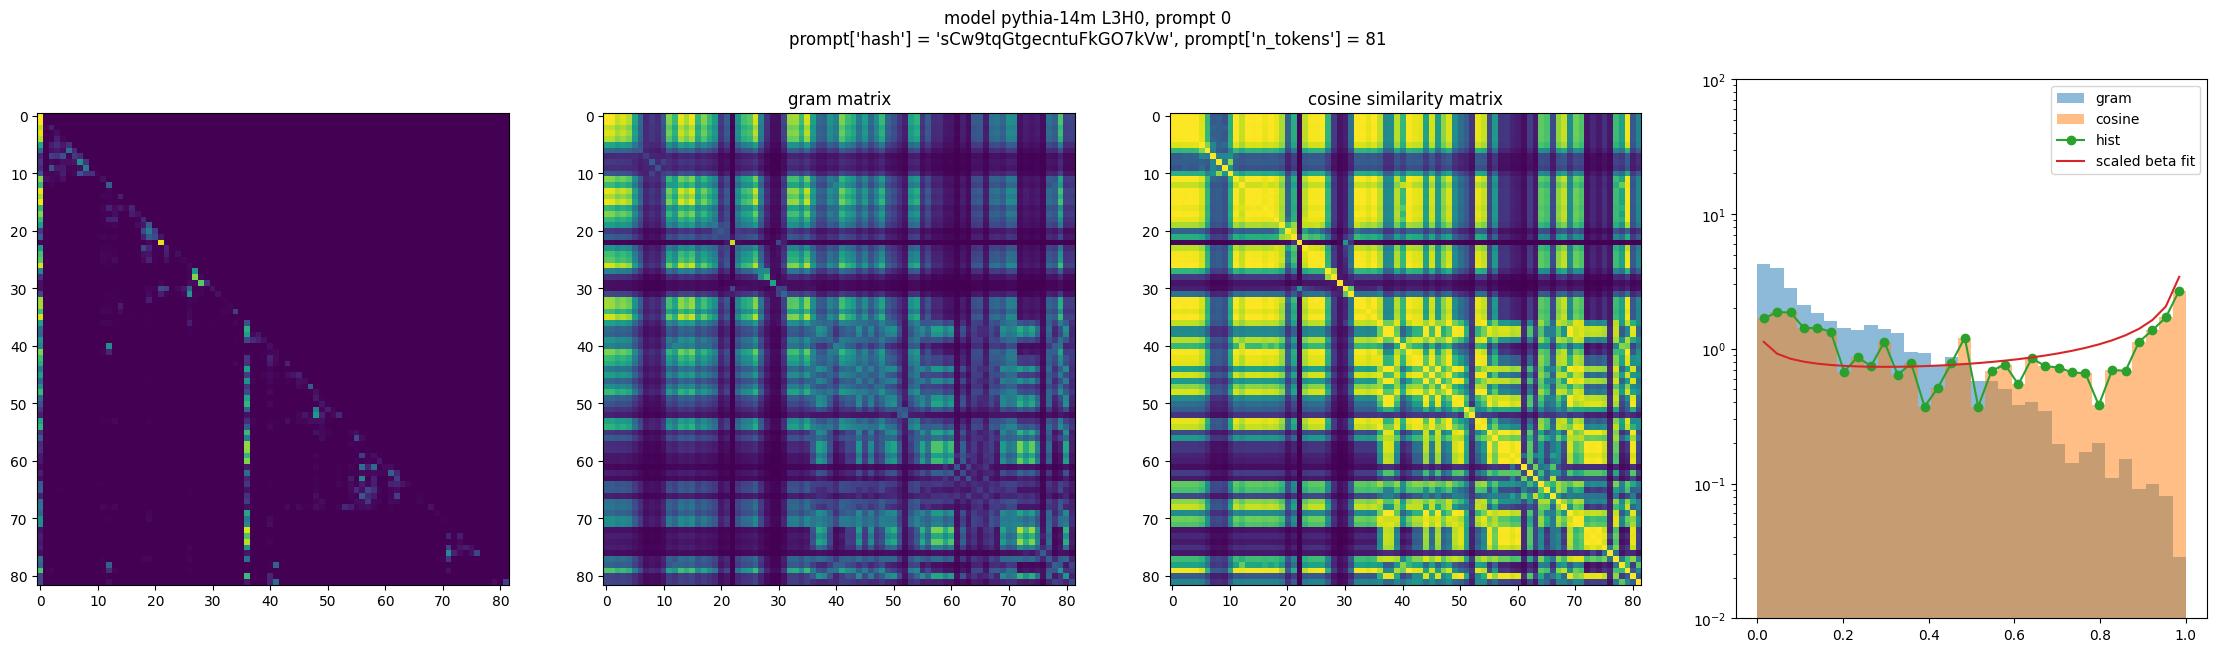

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 4, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.07 σ=0.18 x̃=0.00 R=[0.00,1.00] ℙ=|█▅▄▄▃▄▄| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=3.95 x̃=0.17 R=[0.04,22.94] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.09521908450085974, 0.4636166169170044, 9.322621264097554e-26, 1.5035347060313775)


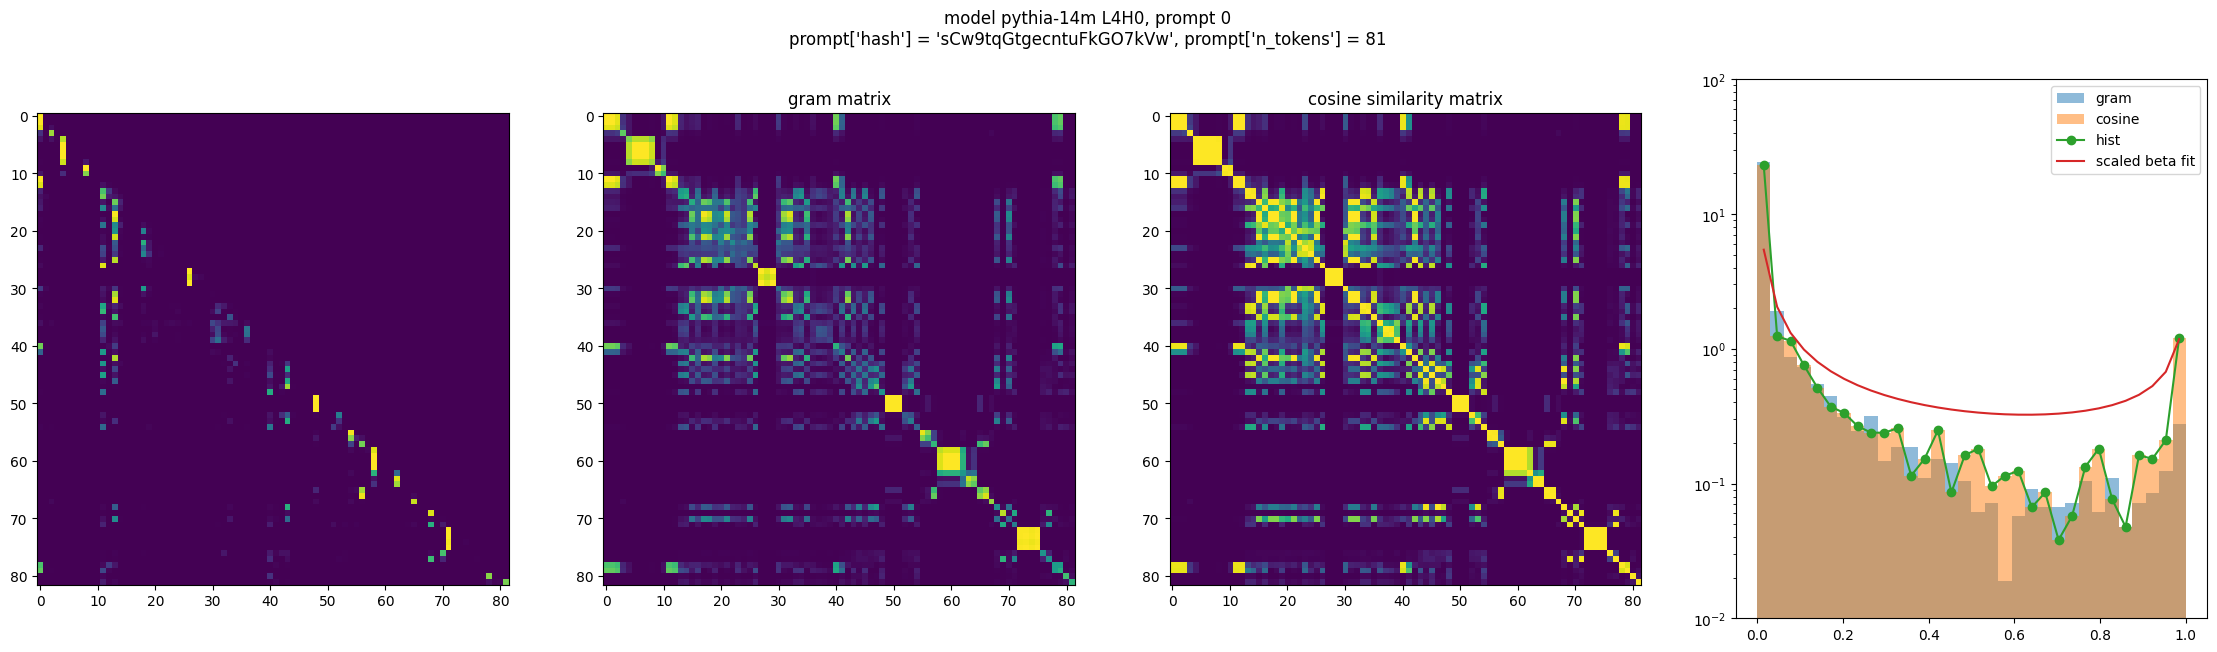

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 5, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.15 σ=0.33 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▄▄▄▄▆| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=4.37 x̃=0.04 R=[0.00,25.10] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.04920645943525809, 0.17331464425579254, -1.764725893910211e-28, 1.003372280615186)


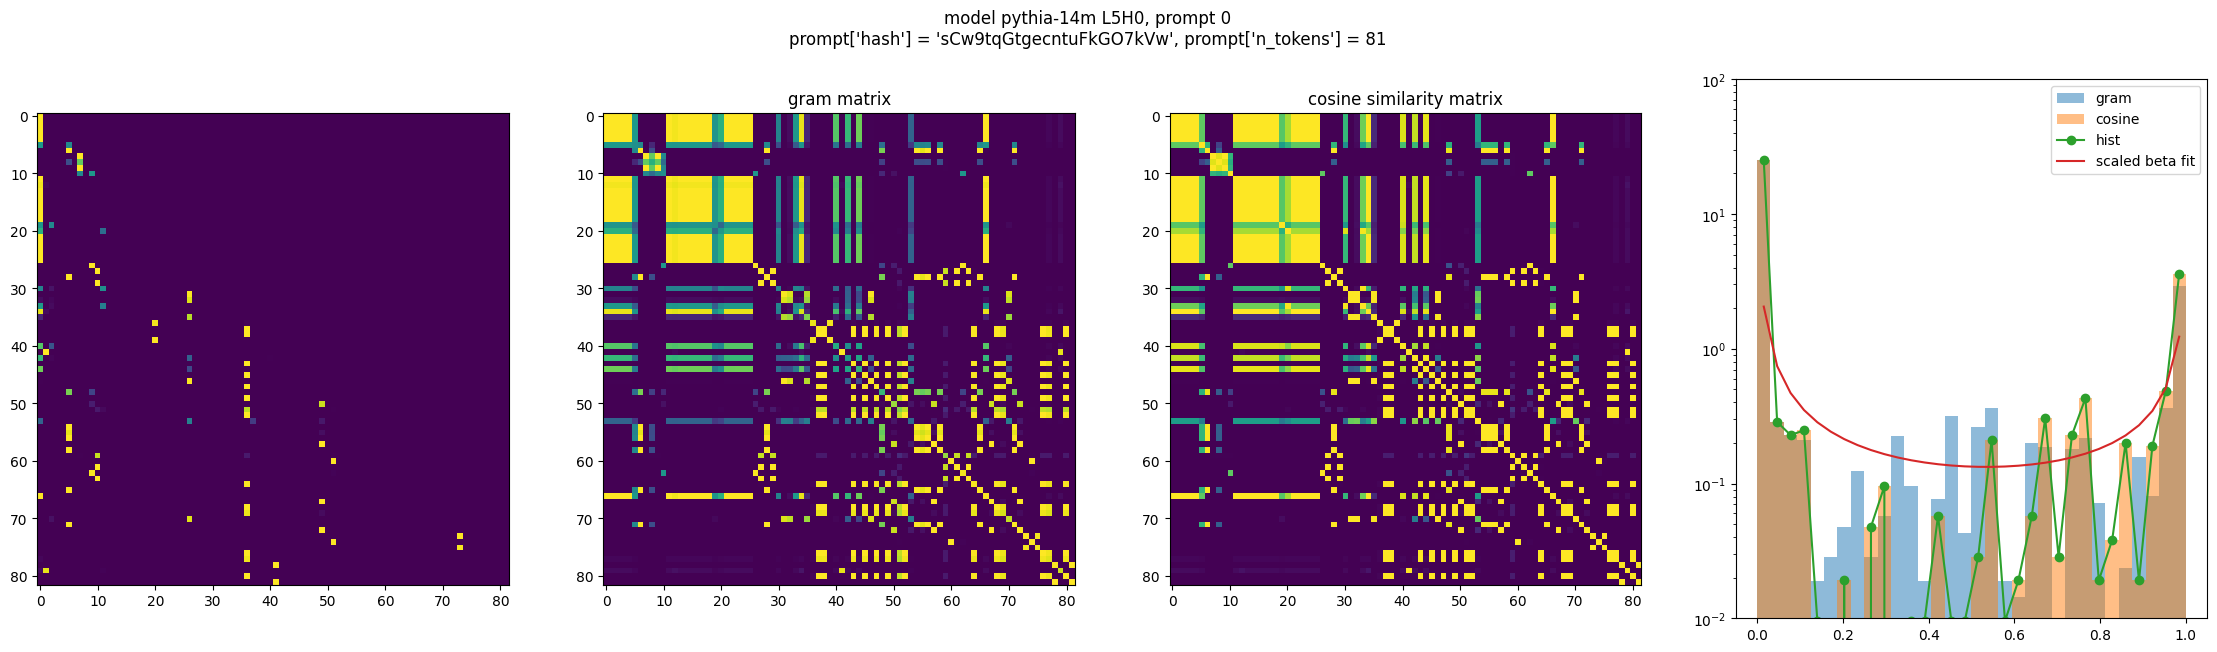

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 0, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.08 σ=0.13 x̃=0.03 R=[0.00,1.00] ℙ=|█▅▄▄▃▂▁| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.37 x̃=0.40 R=[0.09,6.60] ℙ=|█▄▁▁▁ ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.37555815563280265, 0.9805185519965721, 0.00015392895929628738, 0.9998462730898087)


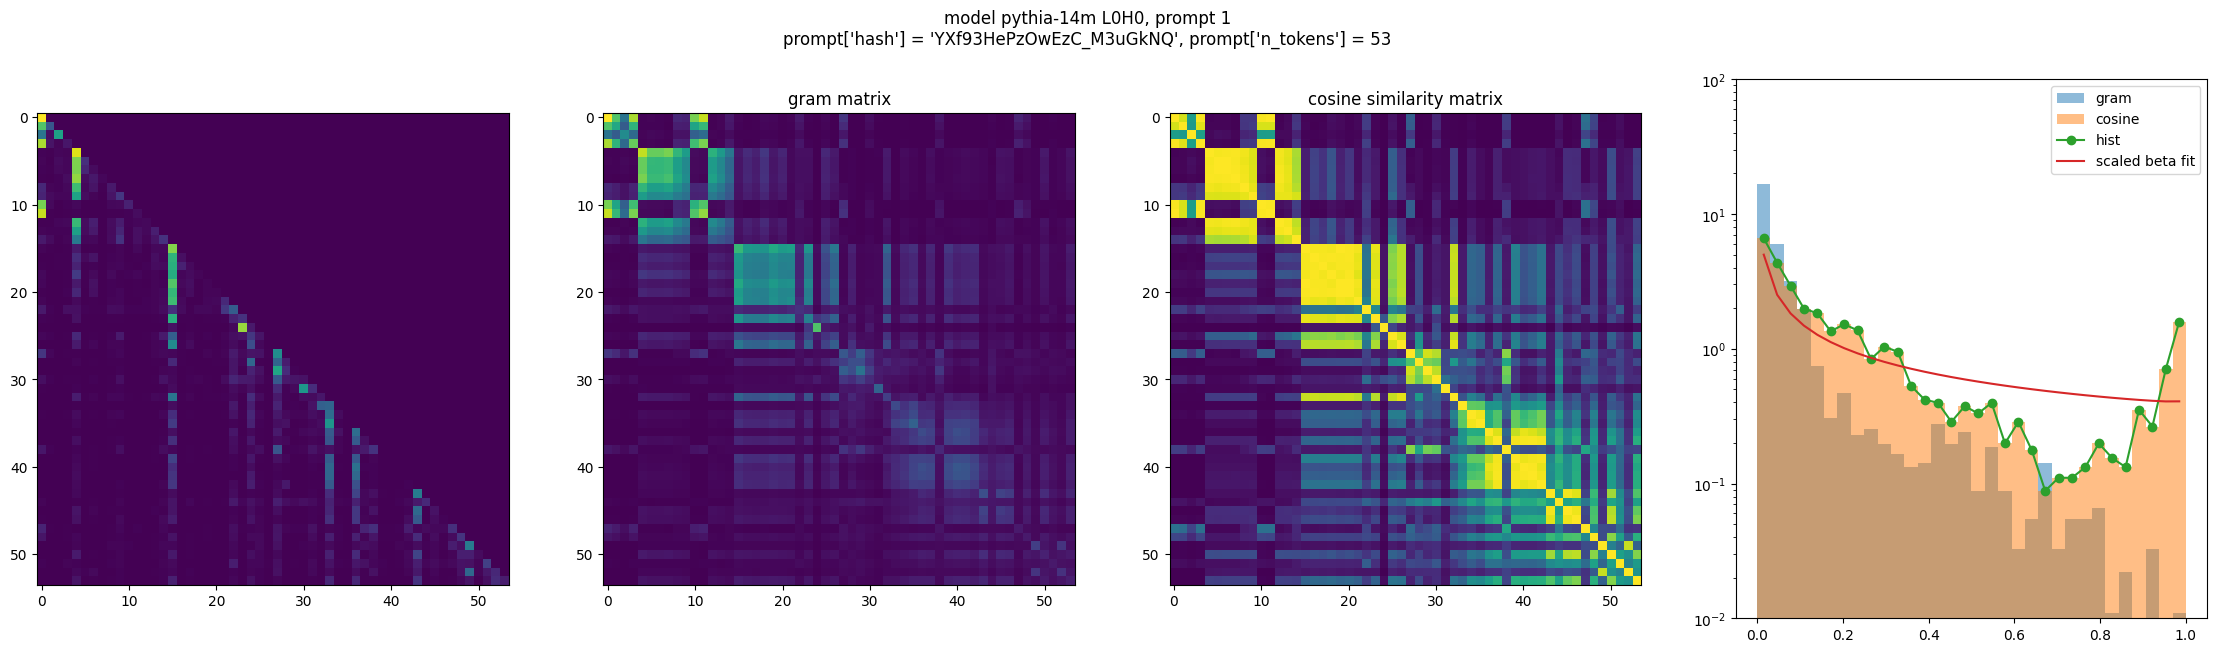

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 1, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.02 σ=0.11 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▂▃▃▁▂| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=5.24 x̃=0.02 R=[0.00,30.19] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.28197392851155023, 338.0600061118133, 2.256659980621088e-24, 11.361425114898601)


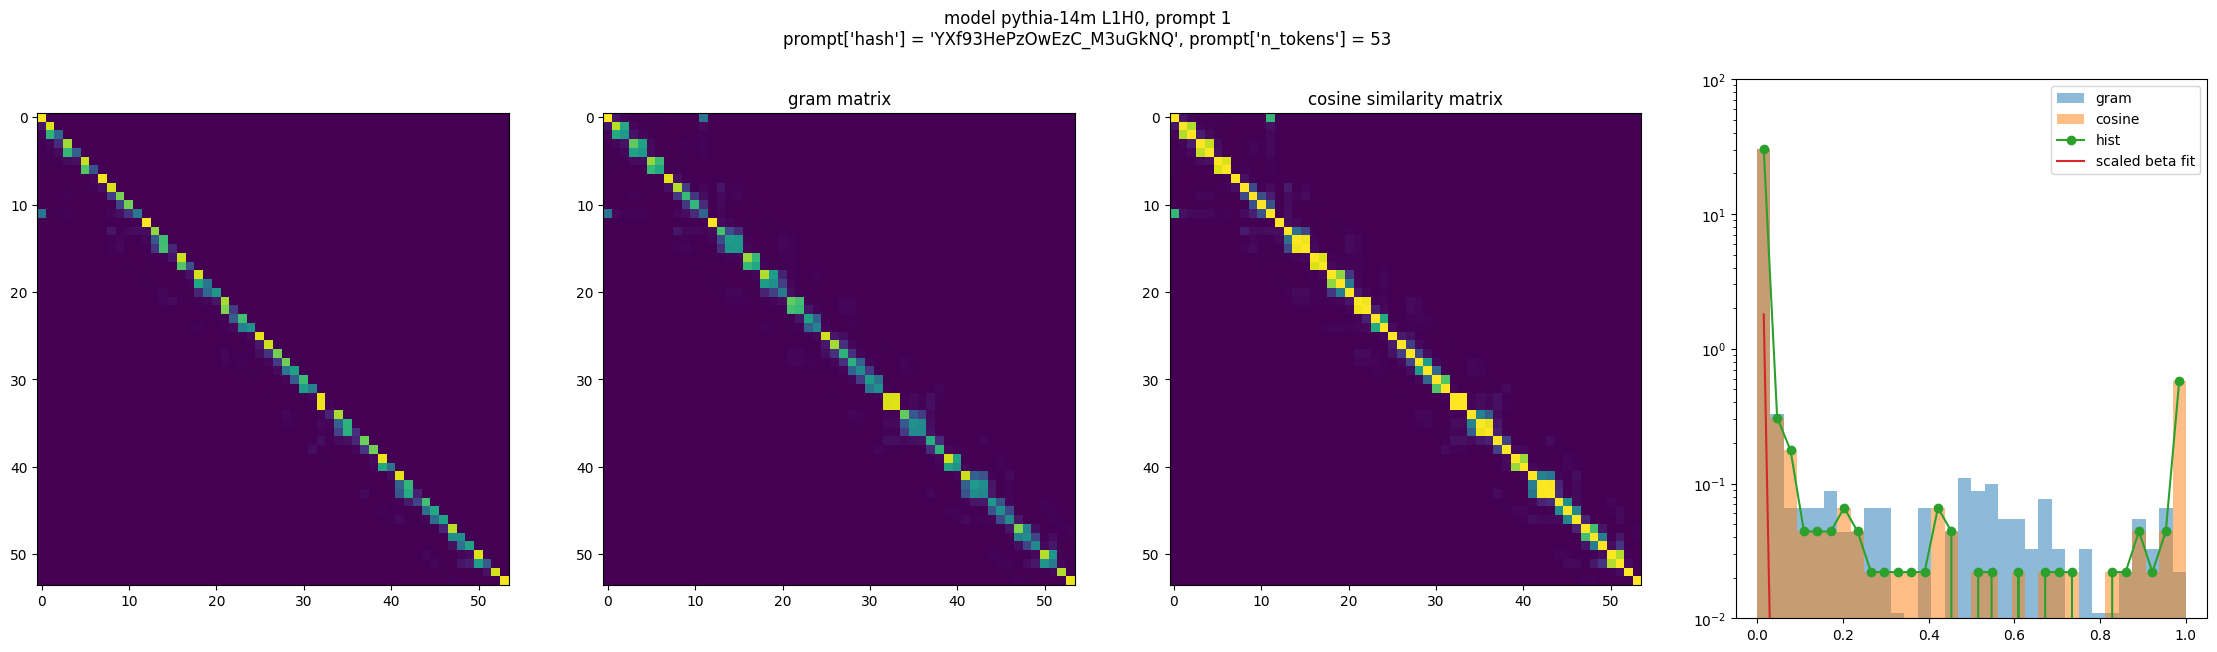

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 2, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.08 σ=0.08 x̃=0.05 R=[0.01,1.00] ℙ=|█▄▄▃▂▁ | shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.71 x̃=0.89 R=[0.00,2.22] ℙ=|██▇▆▆▂█| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (4.175422753916655, 10.760582140598462, 0.015848915174273583, 1.7508037174114324)


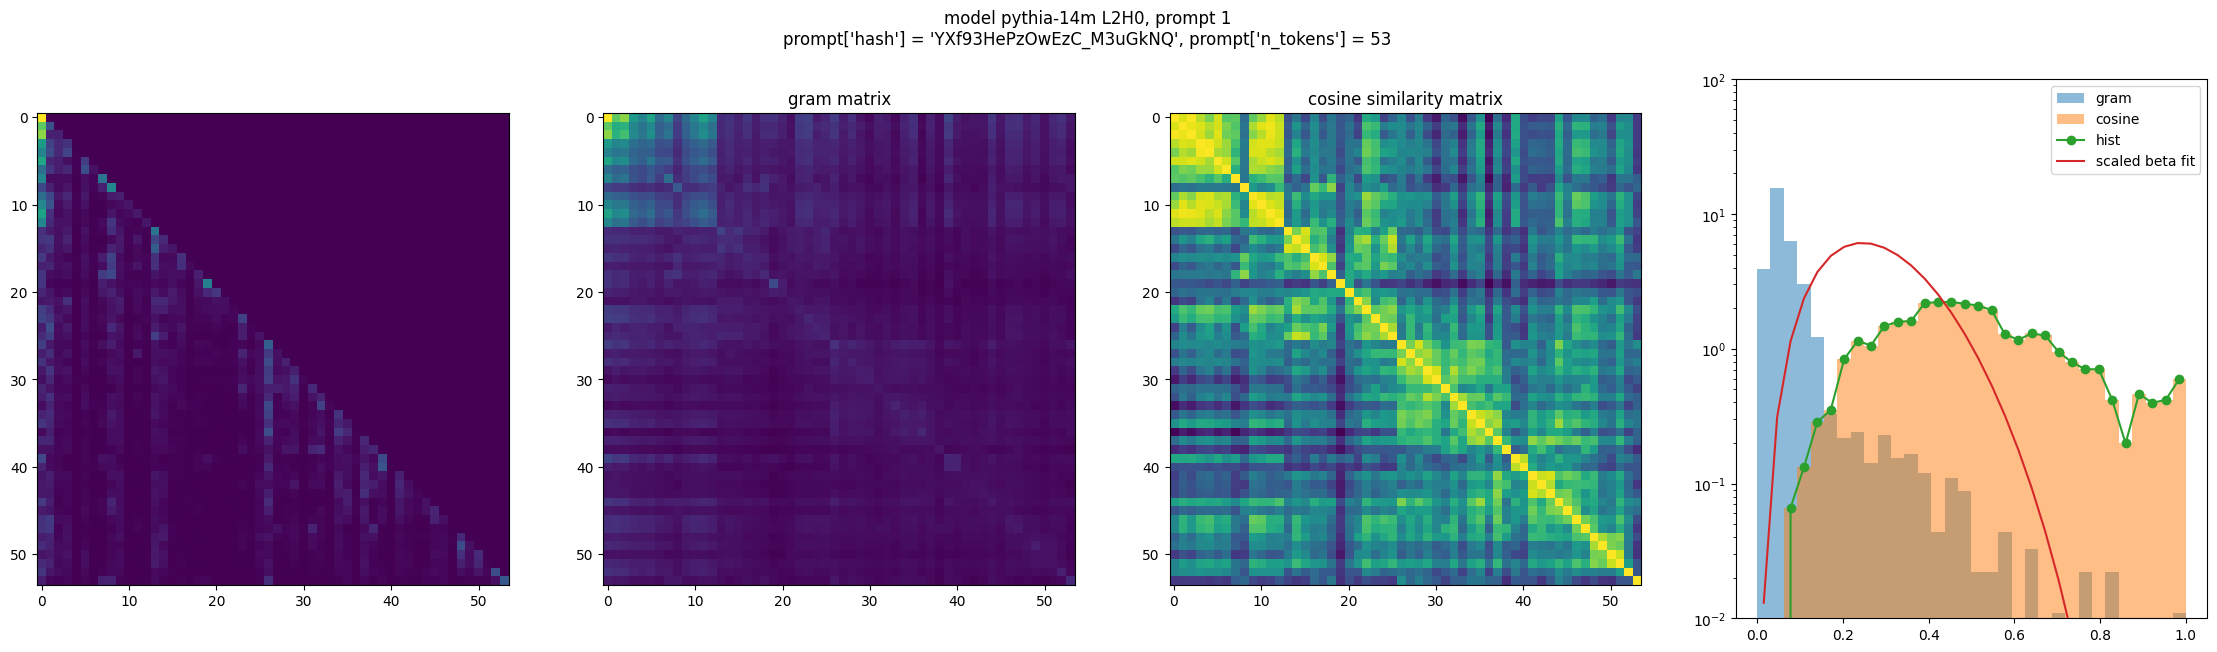

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 3, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.40 σ=0.24 x̃=0.36 R=[0.01,1.00] ℙ=|▇▇█▇▇▆▆| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.36 x̃=0.70 R=[0.00,7.39] ℙ=|█▆▁   ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (2.1378133014032343, 0.6530854826626994, -0.08003848632021188, 1.0800389130559023)


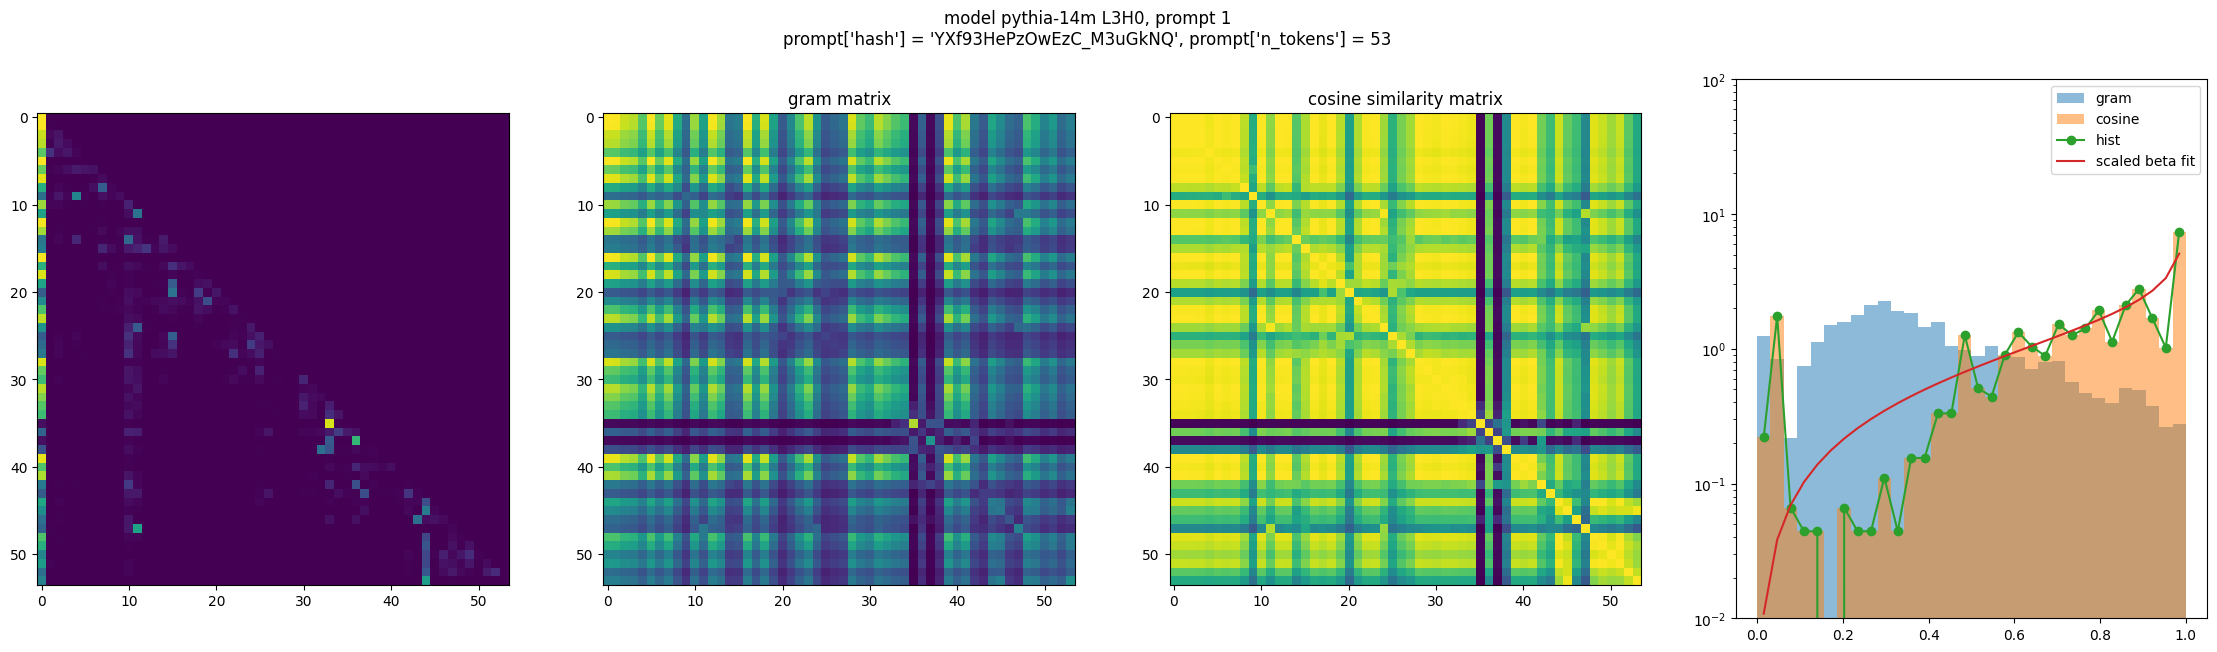

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 4, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.28 σ=0.31 x̃=0.17 R=[0.00,1.00] ℙ=|█▆▆▄▅▅▆| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.32 x̃=0.57 R=[0.09,6.64] ℙ=|█▄   ▁▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.41182202324180955, 0.44110783881663684, -0.00745379948404773, 1.007454216476718)


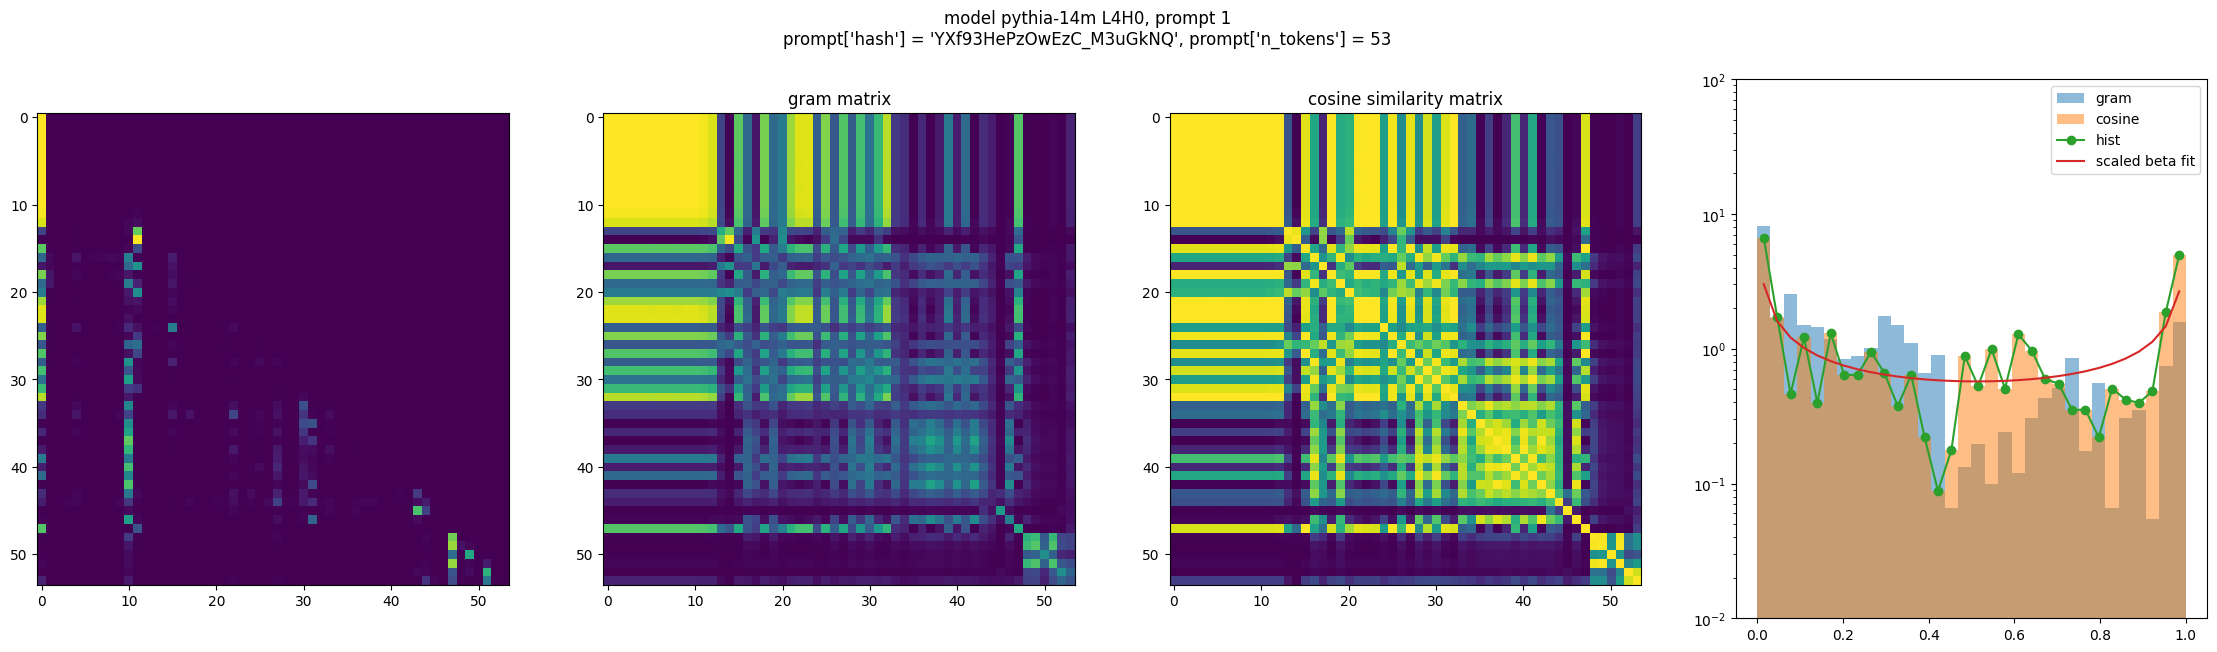

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 5, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.38 σ=0.44 x̃=0.02 R=[0.00,1.00] ℙ=|█▃▆▃▃▅▇| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=3.27 x̃=0.04 R=[0.00,16.32] ℙ=|█   ▁ ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (1.7051956643494761, 0.5729554080211932, -0.2628828739465919, 1.262883019224134)


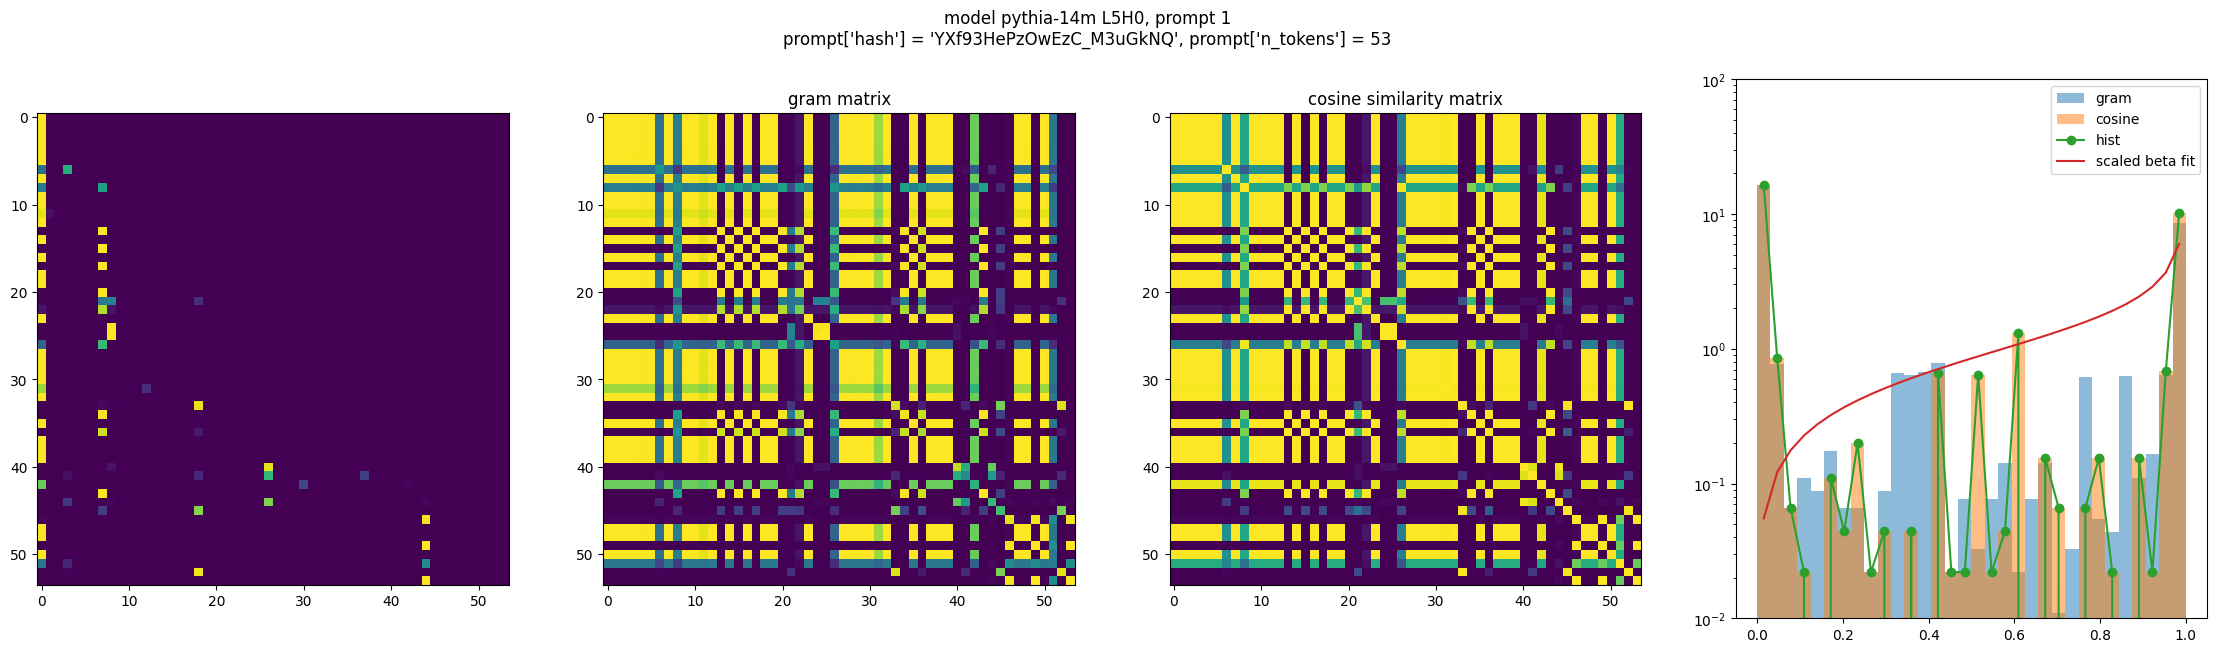

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 0, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.05 σ=0.07 x̃=0.03 R=[0.00,1.00] ℙ=|█▄▃▂▁▁ | shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.06 x̃=0.50 R=[0.17,4.85] ℙ=|█▃▄ ▂ ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.682359823374088, 2.9365632430120825, 0.0004076433171378239, 1.3530091649494373)


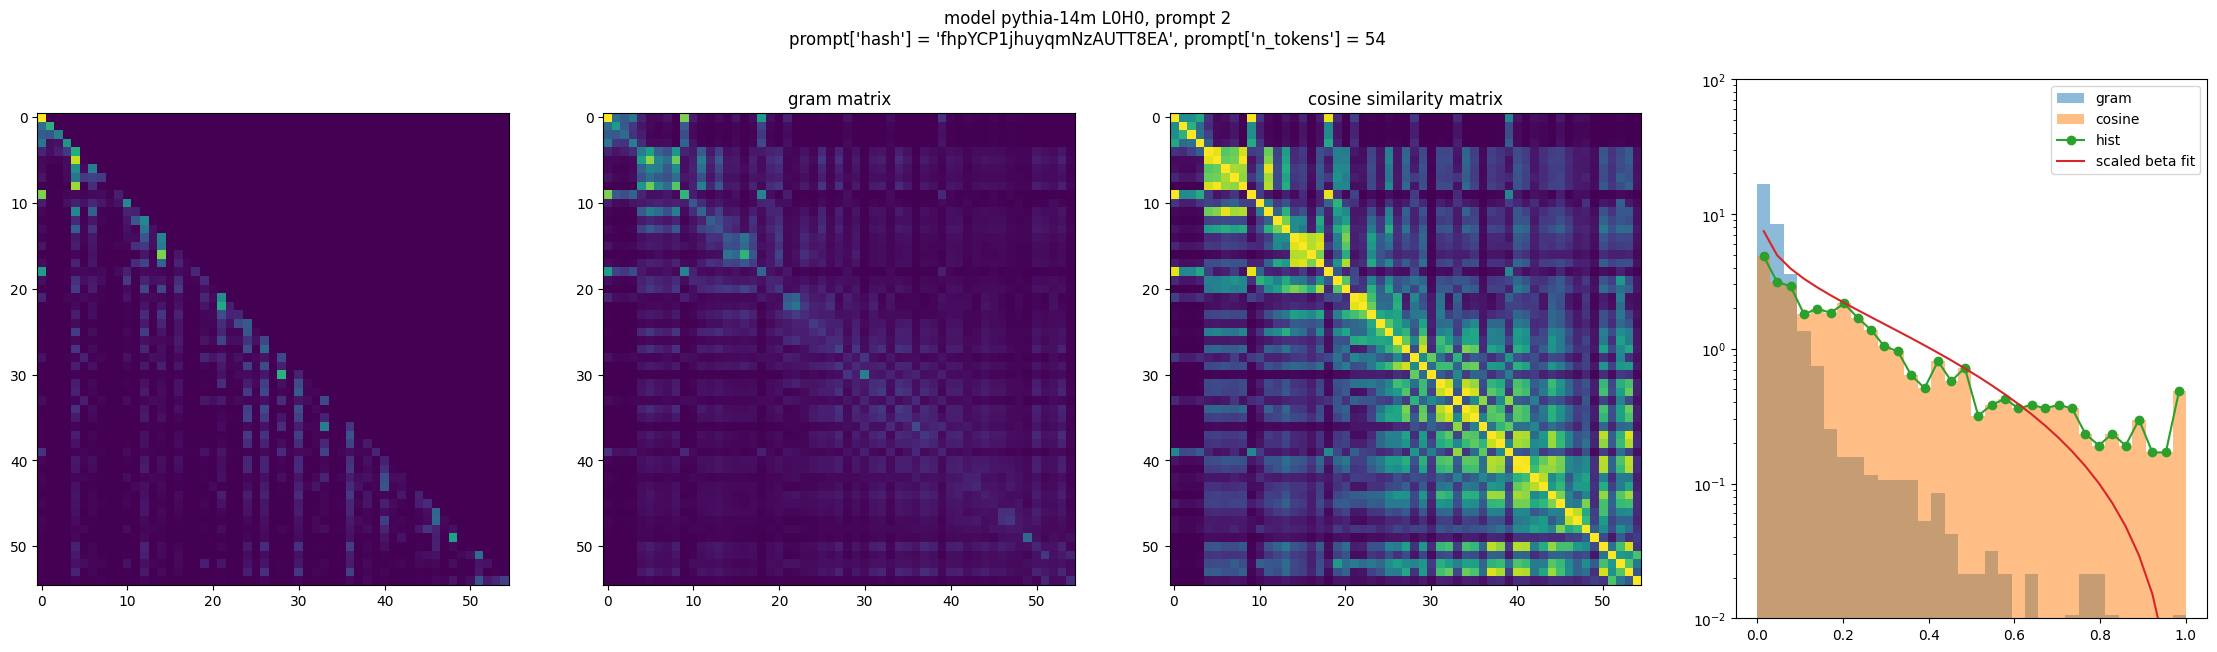

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 1, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.02 σ=0.11 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▂▃▃▂▂| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=5.16 x̃=0.04 R=[0.00,29.74] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.15676796598680345, 429.84609888049454, 2.0698993386604637e-22, 12.68876912727978)


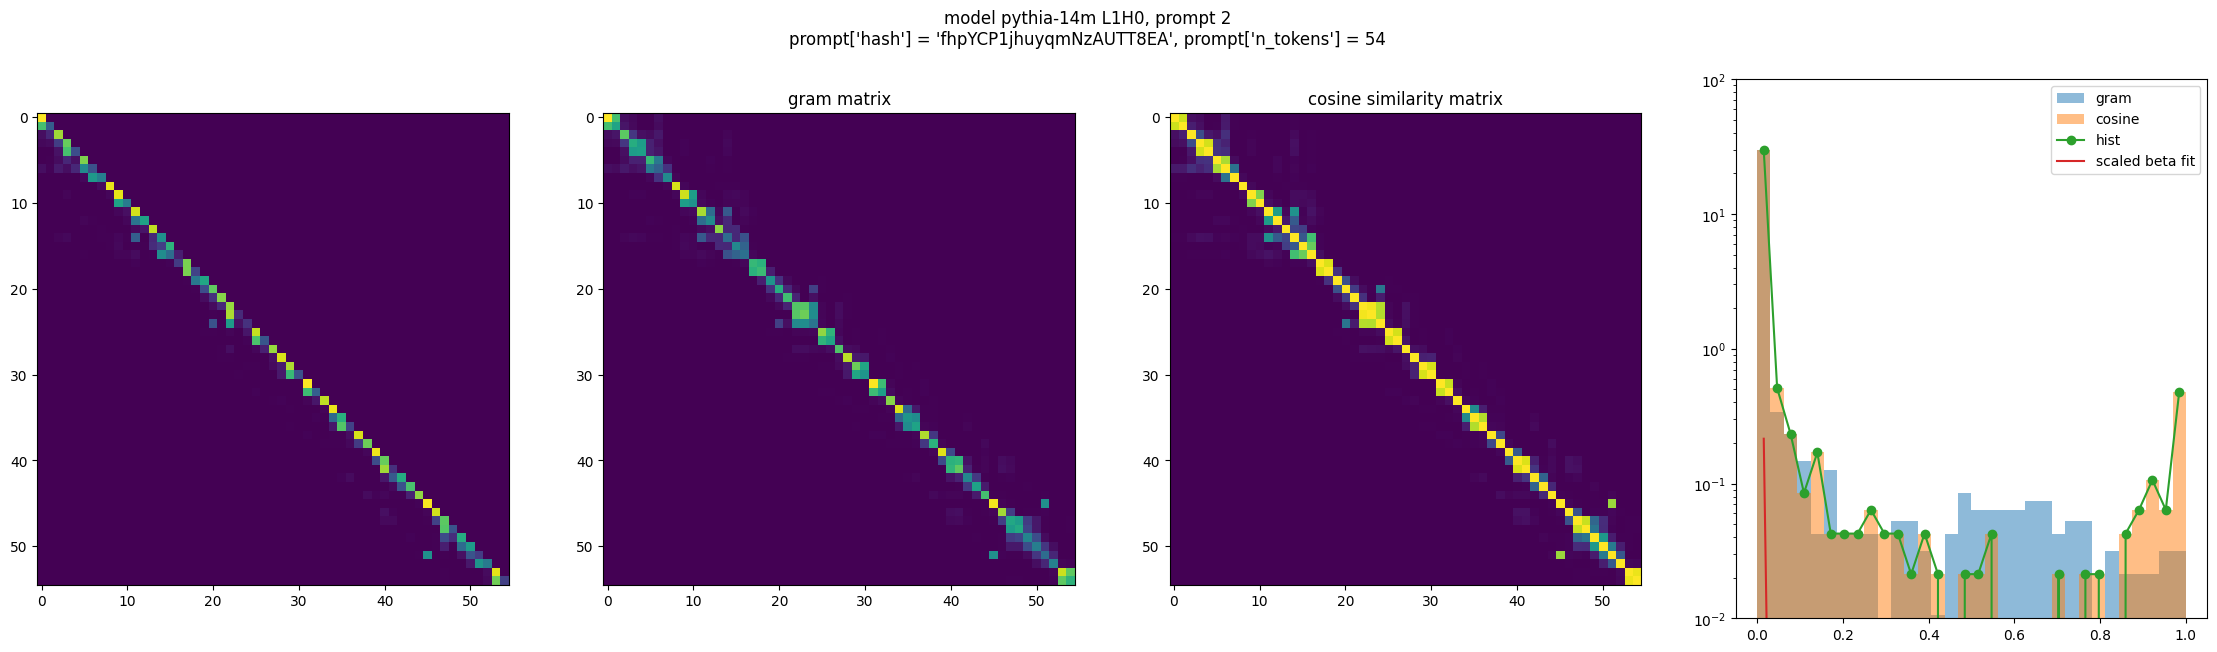

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 2, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.07 σ=0.09 x̃=0.05 R=[0.01,1.00] ℙ=|█▅▃▃▁▂▂| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.49 x̃=1.03 R=[0.13,2.02] ℙ=|▅▆▆▅█▂▄| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (1.15454882146483, 2.010402365660575, 0.015501722797915507, 1.0619967715233427)


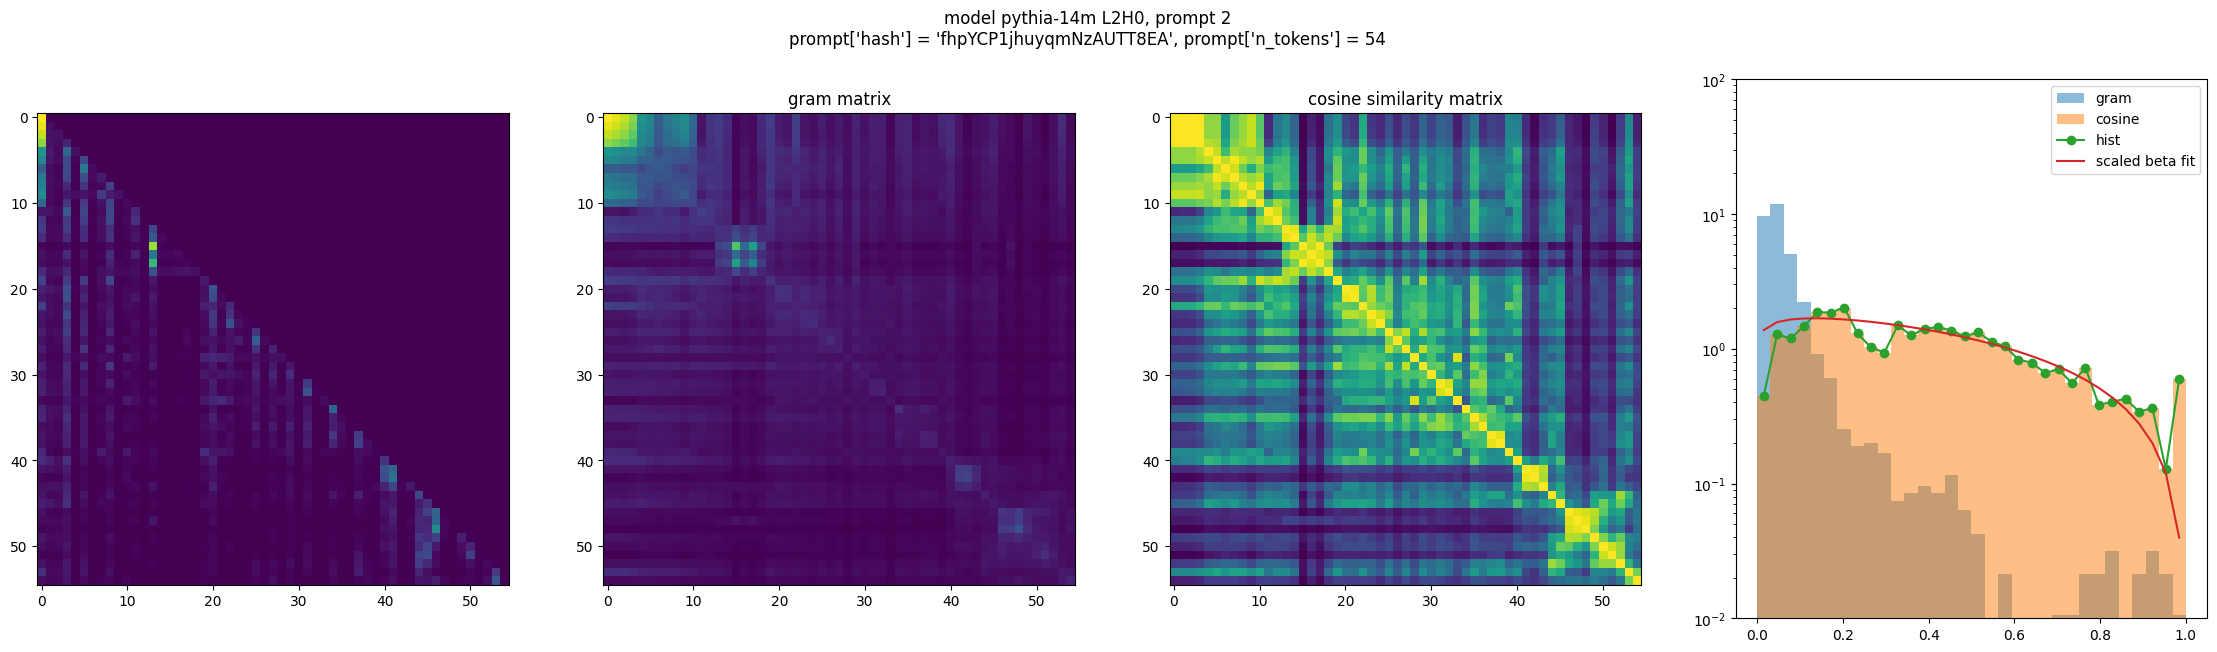

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 3, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.14 σ=0.13 x̃=0.11 R=[0.00,1.00] ℙ=|█▇▅▄▃▂▁| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.44 x̃=0.90 R=[0.34,2.62] ℙ=|▅█▆▄  ▂| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.6851052363535657, 0.6563149486445439, -0.09758180283002343, 1.0975822616610822)


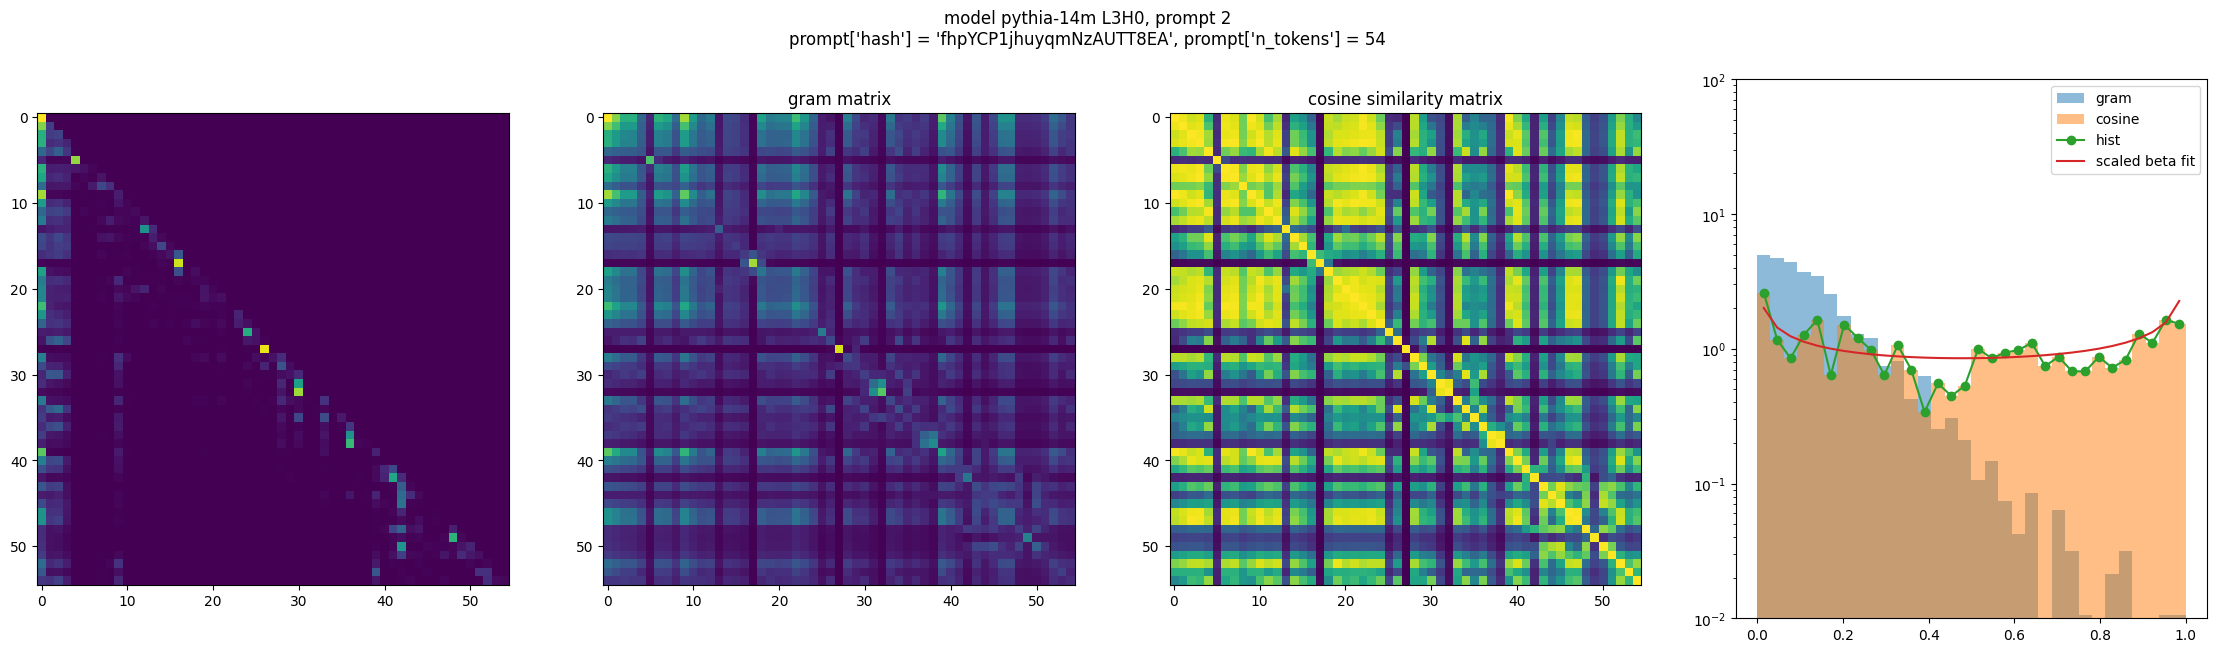

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 4, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.19 σ=0.28 x̃=0.07 R=[0.00,1.00] ℙ=|█▆▅▄▄▄▅| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=2.01 x̃=0.48 R=[0.15,11.58] ℙ=|█▁▁   ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.3945073480387842, 0.320520835291507, -0.06515663657038626, 1.0651568143675993)


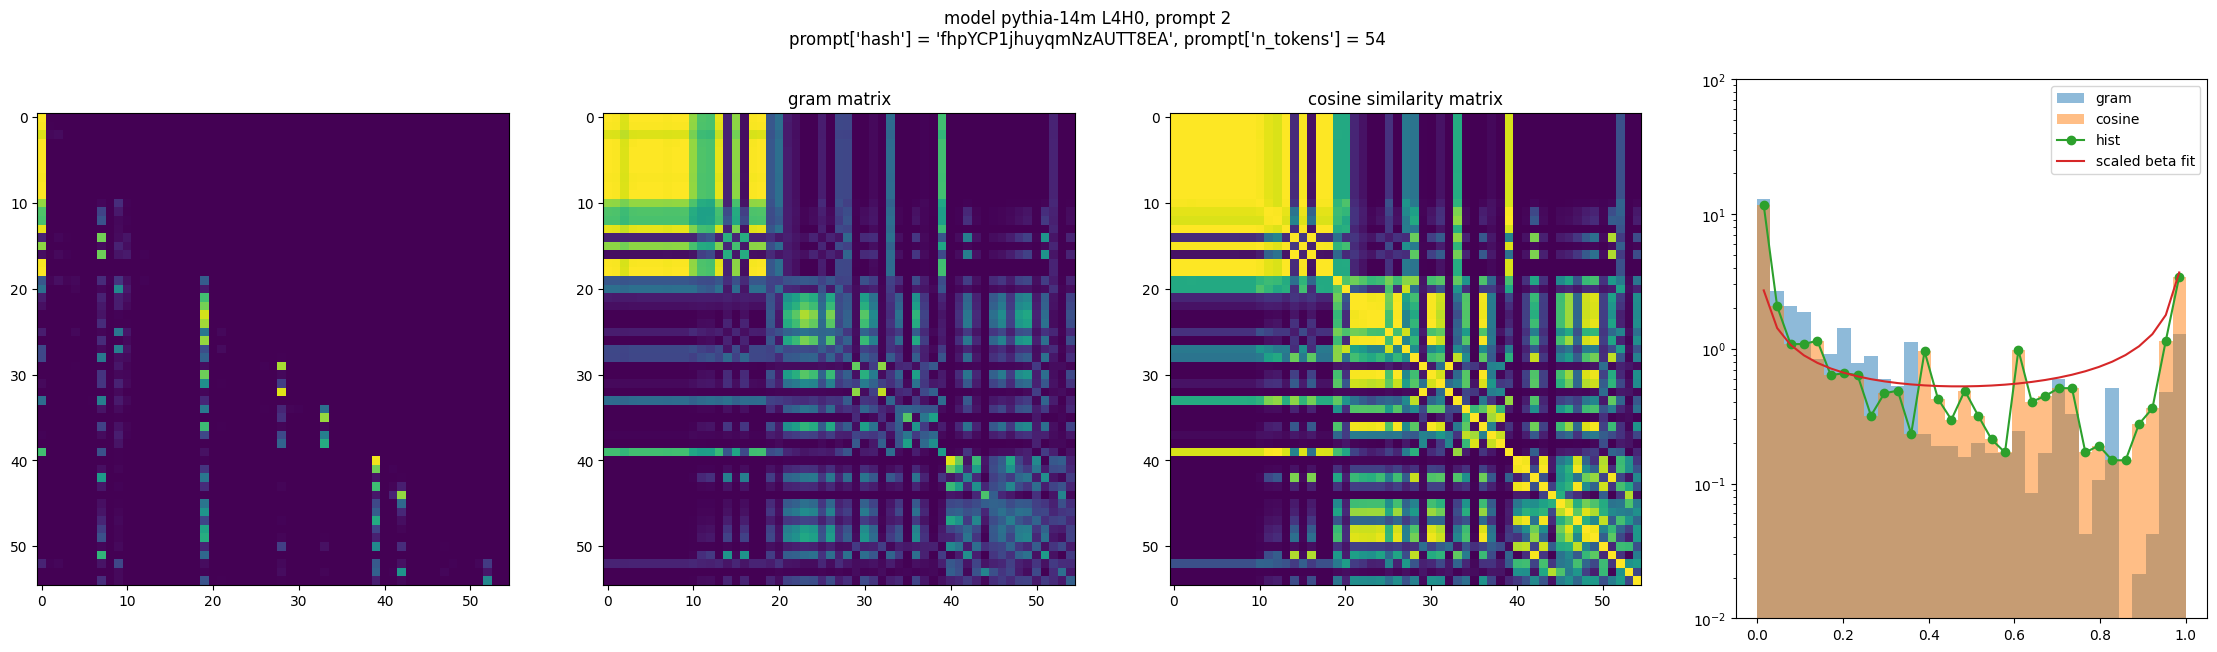

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 5, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.11 σ=0.23 x̃=0.00 R=[0.00,1.00] ℙ=|█▅▅▄▄▃▄| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=3.53 x̃=0.32 R=[0.04,20.58] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.1529477759354219, 0.6032427667722643, 2.4734870215247296e-24, 1.04120053048271)


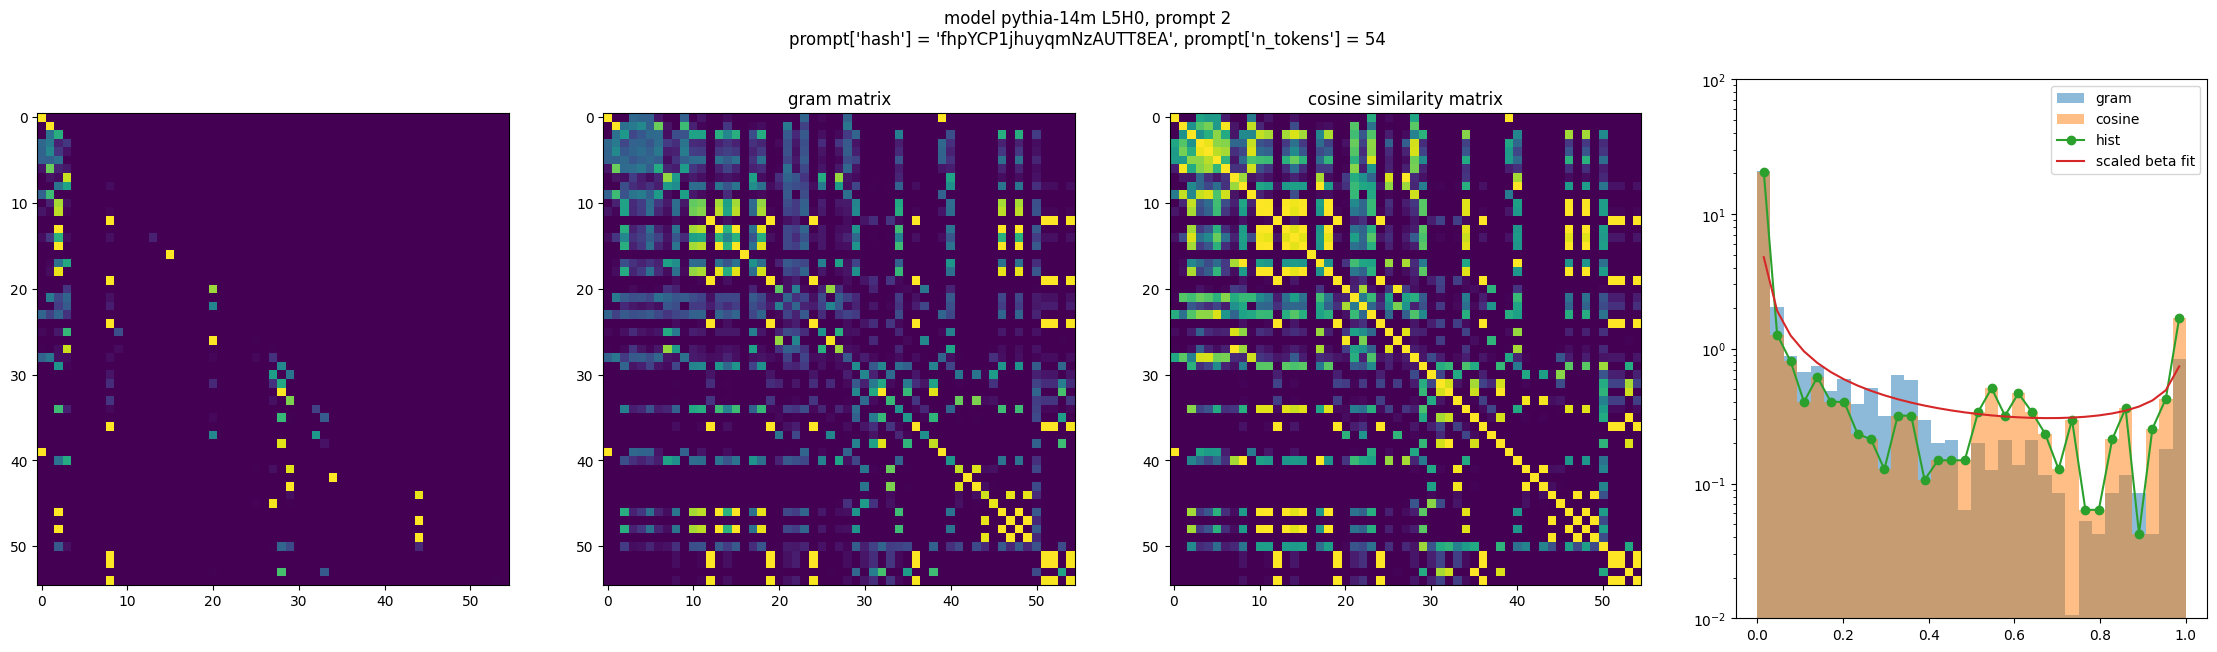

In [ ]:
def fig_gram(A: np.ndarray, axs: list[plt.Axes], p_idx: int, lyr: int, head: int):
	n_ctx: int = A.shape[0]
	ax_raw, ax_gram, ax_cossim, ax_hist = axs

	ax_raw.imshow(A)

	mat_gram = A @ A.T
	ax_gram.imshow(mat_gram)
	ax_gram.set_title("gram matrix")
	mat_cos = cosine_similarity_matrix(A)
	ax_cossim.imshow(mat_cos)
	ax_cossim.set_title("cosine similarity matrix")

	bins: Bins = Bins(scale="lin")
	ax_hist.set_yscale("log")
	ax_hist.set_xscale("linear")
	x_hist, _ = np.histogram(
		# mat_gram.flatten(),
		mat_cos.flatten(),
		bins=bins.edges,
		density=True,
	)
	# x_hist = x_hist / n_ctx
	ax_hist.hist(
		mat_gram.flatten(), bins=bins.edges, density=True, alpha=0.5, label="gram"
	)
	ax_hist.hist(
		mat_cos.flatten(), bins=bins.edges, density=True, alpha=0.5, label="cosine"
	)
	ax_hist.plot(bins.centers, x_hist, "-o", label="hist")

	dbg_tensor(mat_gram.flatten())
	dbg_tensor(x_hist)
	alpha_est, beta_est, loc, scale = stats.beta.fit(mat_cos, method="MM")
	# popt, pcov = curve_fit(
	# 	scaled_beta,
	# 	bins.centers,
	# 	x_hist,
	# 	p0=(1.0, 1.0, 1.0),
	# 	maxfev=999999,
	# )
	# print(f"popt: {popt}")
	# print(f"pcov: {pcov}")
	dbg((alpha_est, beta_est, loc, scale))
	ax_hist.plot(
		bins.centers,
		scaled_beta(bins.centers, alpha_est, beta_est, scale),
		label="scaled beta fit",
	)
	ax_hist.set_ylim(1e-2, 1e2)

	ax_hist.legend()
	# ax_gram_col.imshow(A @ A_col0.T)
	# ax_gram_col.set_title("gram matrix col0")
	# ax_cossim_col.imshow(cosine_similarity_matrix(A_col0))
	# ax_cossim_col.set_title("cosine similarity matrix col0")


plot_figs(
	n_figures=4,
	model_cfg=MODEL_CFG,
	prompt_dicts=PROMPTS,
	activations=ACTIVATIONS,
	# figure_func=fig,
	figure_func=fig_gram,
	prompts=[0, 1, 2],
	layers=None,
	heads=[0],
)

plt.show()